In [1]:
import os
import json
import random
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel

In [2]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests

# -------------------------------
# Device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
TRAIN_IMAGE_DIR = "dataset/flickr30k_images/train"
TRAIN_CAPTIONS_DIR = "dataset/captions-train.csv"

TEST_IMAGE_DIR = "dataset/flickr30k_images/test"
TEST_CAPTIONS_DIR = "dataset/captions-test.csv"

FAISS_OUT = "flickr30k_clip_images.faiss"
JSON_OUT = "image_metadata.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [4]:
# -------------------------------
# Load BLIP model & processor
# -------------------------------
BLIP_model_name = "Salesforce/blip-image-captioning-base"  # or use '-large' for bigger model

BLIP_processor = BlipProcessor.from_pretrained(BLIP_model_name, local_files_only=True, use_fast=True)
BLIP_model = BlipForConditionalGeneration.from_pretrained(BLIP_model_name, local_files_only=True).to(DEVICE)

# Freeze BLIP parameters
BLIP_model.eval()
for param in BLIP_model.parameters():
    param.requires_grad = False

In [5]:
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

CLIP_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME, local_files_only=True, use_fast=True)
CLIP_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, local_files_only=True).to(DEVICE)

# Freeze CLIP parameters
CLIP_model.eval()
for param in CLIP_model.parameters():
    param.requires_grad = False

embedding_dim = CLIP_model.visual_projection.out_features

In [6]:
class Flickr30KImageDataset(Dataset):
    """
    Dataset notes:
    - Images are named as integers with .jpg extension (e.g. 14121.jpg)
    - captions CSV has columns: image_name, caption_idx, caption
    - Multiple captions per image
    """

    def __init__(self, image_dir, captions_dir, processor): # Processor: CLIPProcessor
        self.image_dir = image_dir
        self.processor = processor

        # Load captions CSV and group captions by image
        df = pd.read_csv(captions_dir)
        self.captions_per_image = df.groupby("image_name")["caption"].apply(list).to_dict()

        # Load images based on the names in the captions dataset
        self.image_names = [
            img_name for img_name in self.captions_per_image.keys()
            if os.path.exists(os.path.join(self.image_dir, img_name))
        ]

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        # Preprocess to tensor using CLIPProcessor, returns shape [1, 3, 224, 224], so squeeze to [3, 224, 224]
        processed = self.processor(images=image, return_tensors="pt")
        
        if isinstance(self.processor, CLIPProcessor):
            image_tensor = processed['pixel_values'].squeeze(0)
        else:
            image_tensor = processed['pixel_values']

        captions = self.captions_per_image[image_name]

        return {
            "image_tensor": image_tensor.to(DEVICE), 
            "image_name": image_name,
            "captions": captions
        }
        
    def __len__(self):
        return len(self.image_names)
    

class Flickr30KRawImageDataset(Dataset):
    def __init__(self, image_dir, captions_dir): # Processor: CLIPProcessor
        self.image_dir = image_dir
        
        df = pd.read_csv(captions_dir)
        self.image_names = df['image_name'].unique()

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")
        return np.array(image)
        
    def __len__(self):
        return len(self.image_names)


# train_dataset = Flickr30KImageDataset(TRAIN_IMAGE_DIR, TRAIN_CAPTIONS_DIR, processor)
test_dataset  = Flickr30KRawImageDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_DIR)
train_dataset = Flickr30KRawImageDataset(TRAIN_IMAGE_DIR, TRAIN_CAPTIONS_DIR)

test_dataset_CLIP  = Flickr30KImageDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_DIR, CLIP_processor)
test_dataset_BLIP  = Flickr30KImageDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_DIR, BLIP_processor)

In [7]:
with open(JSON_OUT, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print(metadata["0"])  # keys: 'title', 'captions', etc.


{'image_name': '1000092795.jpg', 'captions': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young  White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .']}


In [8]:
faiss_index = faiss.read_index(FAISS_OUT)
print(f"Number of vectors in index: {faiss_index.ntotal}")

Number of vectors in index: 30783


In [9]:
def display_image(np_image):    
    plt.figure(figsize=(4, 4))
    plt.imshow(np_image)
    plt.axis('off')  # Turn off axis labels
    plt.title("Test Image")
    plt.show()

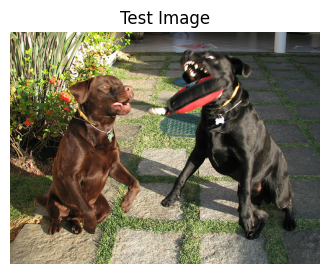

Query image captions:
The Chocolate Lab jumps too late to get the toy as the Black Lab captures it in the driveway .
A brown and black lab are outside and the black lab is catching a toy in its mouth .
A black dog and a brown dog play with a red toy on a courtyard .
A black dog and a brown dog are jumping up to catch a red toy .
Black dog snaps at red and black object as brown dog lunges .


In [10]:
SAMPLE_IDX = 5
display_image(test_dataset[SAMPLE_IDX])
print("Query image captions:")
print(*test_dataset_CLIP[SAMPLE_IDX]['captions'], sep='\n')

Distances: [[0.9180721  0.8862153  0.87490803]]


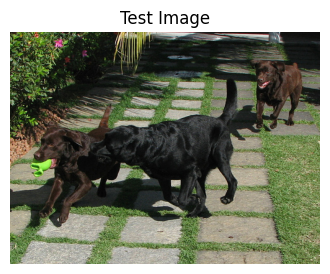

1454678644.jpg
A big black dog chases a big brown dog with a green object in his mouth while another big brown dog tags behind .
A brown dog holds an object in its mouth while a black dog tries to take it away . Another brown dog looks on .
Three dogs fight for a green chew toy on a stone walkway .
Three dogs running together on a paved walkway .
Two dogs chase a third dog with a toy .



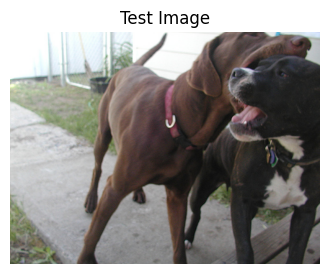

2136992638.jpg
Two dogs  one brown  the other black and white  are playing on a sidewalk .
A brown and a black dog are wearing collars and playing with each other .
Two dogs  one brown and one black  playing with each other .
The brown dog with a red collar is biting the black dog .
A brown dog biting a black dog on a sidewalk



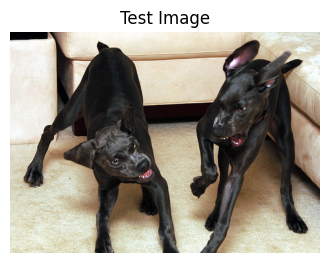

687513087.jpg
Two black dogs fight with each other  with their teeth bared  in a plush carpeted room .
Two black dogs are bearing their teeth beside a white couch .
Two black dogs are fighting in front of a tan sofa .
Two large black dogs are snarling at each other .
Two black dogs play or fight together .



In [11]:
def retrieve_k_similar_images(query, k=1, processor=None):
    if processor is not None:
        query = processor(images=query, return_tensors="pt")
        
    query = query['image_tensor'].unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        embedding = CLIP_model.get_image_features(query)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
        
    embedding = embedding.cpu().numpy().astype(np.float32)
    distance, idx = faiss_index.search(embedding, k=k)
    
    print("Distances:", distance)
    
    return idx

k = 3
retrieved_idx = retrieve_k_similar_images(test_dataset_CLIP[SAMPLE_IDX], k)
retrieved_captions = []

for idx in retrieved_idx[0]:
    display_image(train_dataset[idx])
    print(metadata[str(idx)]['image_name'])
    captions = metadata[str(idx)]['captions']
    print(*captions, sep='\n', end='\n\n')
    
    for caption in captions:
        retrieved_captions.append(caption)

In [12]:
with torch.no_grad():
    output_ids = BLIP_model.generate(pixel_values=test_dataset_BLIP[SAMPLE_IDX]['image_tensor'])

caption = BLIP_processor.decode(output_ids[0], skip_special_tokens=True)
print("Caption:", caption)


Caption: two dogs playing


In [38]:
context = ' '.join(retrieved_captions)

In [39]:
main_caption = "describe this image"
full_prompt = f"{main_caption} in the context of {context}" if context else main_caption
full_prompt

'describe this image in the context of A big black dog chases a big brown dog with a green object in his mouth while another big brown dog tags behind . A brown dog holds an object in its mouth while a black dog tries to take it away . Another brown dog looks on . Three dogs fight for a green chew toy on a stone walkway . Three dogs running together on a paved walkway . Two dogs chase a third dog with a toy . Two dogs  one brown  the other black and white  are playing on a sidewalk . A brown and a black dog are wearing collars and playing with each other . Two dogs  one brown and one black  playing with each other . The brown dog with a red collar is biting the black dog . A brown dog biting a black dog on a sidewalk Two black dogs fight with each other  with their teeth bared  in a plush carpeted room . Two black dogs are bearing their teeth beside a white couch . Two black dogs are fighting in front of a tan sofa . Two large black dogs are snarling at each other . Two black dogs play

In [40]:
processed_context = BLIP_processor(text=full_prompt)
processed_context

{'input_ids': [101, 6235, 2023, 3746, 1999, 1996, 6123, 1997, 1037, 2502, 2304, 3899, 29515, 1037, 2502, 2829, 3899, 2007, 1037, 2665, 4874, 1999, 2010, 2677, 2096, 2178, 2502, 2829, 3899, 22073, 2369, 1012, 1037, 2829, 3899, 4324, 2019, 4874, 1999, 2049, 2677, 2096, 1037, 2304, 3899, 5363, 2000, 2202, 2009, 2185, 1012, 2178, 2829, 3899, 3504, 2006, 1012, 2093, 6077, 2954, 2005, 1037, 2665, 21271, 9121, 2006, 1037, 2962, 19467, 1012, 2093, 6077, 2770, 2362, 2006, 1037, 12308, 19467, 1012, 2048, 6077, 5252, 1037, 2353, 3899, 2007, 1037, 9121, 1012, 2048, 6077, 2028, 2829, 1996, 2060, 2304, 1998, 2317, 2024, 2652, 2006, 1037, 11996, 1012, 1037, 2829, 1998, 1037, 2304, 3899, 2024, 4147, 9127, 2015, 1998, 2652, 2007, 2169, 2060, 1012, 2048, 6077, 2028, 2829, 1998, 2028, 2304, 2652, 2007, 2169, 2060, 1012, 1996, 2829, 3899, 2007, 1037, 2417, 9127, 2003, 12344, 1996, 2304, 3899, 1012, 1037, 2829, 3899, 12344, 1037, 2304, 3899, 2006, 1037, 11996, 2048, 2304, 6077, 2954, 2007, 2169, 2060, 2007

In [41]:
from torch import LongTensor

processed_context_tensor = LongTensor(processed_context['input_ids']).unsqueeze(0).to(DEVICE)
attention_mask = LongTensor(processed_context['attention_mask']).unsqueeze(0).to(DEVICE)
processed_context_tensor.shape

torch.Size([1, 217])

In [42]:
# Generate caption ids
with torch.no_grad():
    # output_ids = BLIP_model.generate(**inputs)
    output_ids = BLIP_model.generate(pixel_values=test_dataset_BLIP[SAMPLE_IDX]['image_tensor'], input_ids=processed_context_tensor)

# Decode caption
caption = BLIP_processor.decode(output_ids[0], skip_special_tokens=True)
print("Caption:", caption)


Caption: describe this image in the context of a big black dog chases a big brown dog with a green object in his mouth while another big brown dog tags behind. a brown dog holds an object in its mouth while a black dog tries to take it away. another brown dog looks on. three dogs fight for a green chew toy on a stone walkway. three dogs running together on a paved walkway. two dogs chase a third dog with a toy. two dogs one brown the other black and white are playing on a sidewalk. a brown and a black dog are wearing collars and playing with each other. two dogs one brown and one black playing with each other. the brown dog with a red collar is biting the black dog. a brown dog biting a black dog on a sidewalk two black dogs fight with each other with their teeth bared in a plush carpeted room. two black dogs are bearing their teeth beside a white couch. two black dogs are fighting in front of a tan sofa. two large black dogs are snarling at each other. two black dogs play or fight tog

In [45]:
with torch.no_grad():
    outputs = BLIP_model.generate(
        input_ids=processed_context_tensor,
        attention_mask=attention_mask,
        pixel_values=test_dataset_BLIP[SAMPLE_IDX]['image_tensor'],
        num_beams=5,
        # max_length=100,
        max_new_tokens=100,
        length_penalty=2.0,
        return_dict_in_generate=True,
        output_attentions=False,
        temperature=1.2
    )

caption = BLIP_processor.decode(outputs.sequences[0], skip_special_tokens=True)
print("Caption:", caption)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Caption: describe this image in the context of a big black dog chases a big brown dog with a green object in his mouth while another big brown dog tags behind. a brown dog holds an object in its mouth while a black dog tries to take it away. another brown dog looks on. three dogs fight for a green chew toy on a stone walkway. three dogs running together on a paved walkway. two dogs chase a third dog with a toy. two dogs one brown the other black and white are playing on a sidewalk. a brown and a black dog are wearing collars and playing with each other. two dogs one brown and one black playing with each other. the brown dog with a red collar is biting the black dog. a brown dog biting a black dog on a sidewalk two black dogs fight with each other with their teeth bared in a plush carpeted room. two black dogs are bearing their teeth beside a white couch. two black dogs are fighting in front of a tan sofa. two large black dogs are snarling at each other. two black dogs play or fight tog

In [135]:
caption

'generate a short caption for this image based on the provided context : caption'

In [17]:
context

'A big black dog chases a big brown dog with a green object in his mouth while another big brown dog tags behind . \n A brown dog holds an object in its mouth while a black dog tries to take it away . Another brown dog looks on . \n Three dogs fight for a green chew toy on a stone walkway . \n Three dogs running together on a paved walkway . \n Two dogs chase a third dog with a toy . \n Two dogs  one brown  the other black and white  are playing on a sidewalk . \n A brown and a black dog are wearing collars and playing with each other . \n Two dogs  one brown and one black  playing with each other . \n The brown dog with a red collar is biting the black dog . \n A brown dog biting a black dog on a sidewalk \n Two black dogs fight with each other  with their teeth bared  in a plush carpeted room . \n Two black dogs are bearing their teeth beside a white couch . \n Two black dogs are fighting in front of a tan sofa . \n Two large black dogs are snarling at each other . \n Two black dogs 

In [139]:
output_ids

tensor([[30522,  2048,  6077,  2652,   102]], device='cuda:0')

In [ ]:
# from transformers import AutoProcessor, AutoModelForVLM
# import PIL
# import numpy as np

def generate_caption_with_context(image_path, additional_context=None):
    # Initialize model and processor
    # model_name = "Salesforce/bloom-vl-2b"  # BLIP
    # # Alternatively, use "facebook/flamingo-430m" for Flamingo (requires appropriate setup)
    # model = AutoModelForVLM.from_pretrained(model_name)
    # processor = AutoProcessor.from_pretrained(model_name)

    # Load and process the image
    image = test_dataset_BLIP[SAMPLE_IDX]['image_tensor']
        # images = np.array(image)

        # Prepare additional context if provided
    main_caption = "describe this image"
    full_prompt = f"{main_caption} in the context of {context}" if context else main_caption

        # Tokenize inputs
    inputs = BLIP_processor(full_prompt, return_tensors="np", padding=True, truncation=True)
    pixel_values = BLIP_processor(image, return_tensors="np")

    # Generate captions using the model
    outputs = BLIP_model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        pixel_values=pixel_values.pixel_values,
        num_beams=5,
        max_length=100,
        length_penalty=2.0,
        return_dict_in_generate=True,
        output_attentions=False,
    )

    # Decode the generated tokens
    decoded_caption = BLIP_processor.decode(outputs[0].sequences[0], skip_special_tokens=True)
    return decoded_caption

# Example usage
image_path = "path_to_your_image.jpg"  # Replace with actual image path
additional_context = "a fluffy cat playing with yarn in a living room"

caption = generate_caption_with_context(image_path, additional_context)
print("Generated Caption:", caption)
